In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Understanding the Data

In [2]:
df = pd.read_csv("ai_ds_job_salaries_2026_cleaned.csv")

df.head()

,job_title,experience_level,employment_type,company_size,industry,company_location_name,remote_ratio,years_experience,education_level,primary_language,team_size,certifications_count,uses_ai_tools_daily,ai_tools_hours_per_week,salary_usd
0,Data Analyst,Lead,Part-time,S,Finance,India,0,14,Bachelors,Python,5,0,True,12,23844
1,Research Scientist,Senior,Full-time,L,Retail,United States,50,8,Masters,SQL,6,1,False,2,170132
2,Machine Learning Engineer,Entry,Full-time,M,Government,United States,0,0,Bootcamp,Python,4,1,True,5,83059
3,Data Engineer,Senior,Full-time,M,Government,Brazil,100,10,Masters,Java,6,2,True,2,29531
4,Data Engineer,Mid,Full-time,M,Education,United States,0,3,Bachelors,Python,13,2,False,4,70105


In [3]:
df.shape

(5000, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   job_title                5000 non-null   object
 1   experience_level         5000 non-null   object
 2   employment_type          5000 non-null   object
 3   company_size             5000 non-null   object
 4   industry                 5000 non-null   object
 5   company_location_name    5000 non-null   object
 6   remote_ratio             5000 non-null   int64 
 7   years_experience         5000 non-null   int64 
 8   education_level          5000 non-null   object
 9   primary_language         5000 non-null   object
 10  team_size                5000 non-null   int64 
 11  certifications_count     5000 non-null   int64 
 12  uses_ai_tools_daily      5000 non-null   bool  
 13  ai_tools_hours_per_week  5000 non-null   int64 
 14  salary_usd               5000 non-null  

In [5]:
df.describe()

,remote_ratio,years_experience,team_size,certifications_count,ai_tools_hours_per_week,salary_usd
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.08000,8.360000,7.935800,1.820600,8.428400,98605.406200
std,41.45428,4.826288,2.647769,1.343866,5.517804,55369.310473
min,0.00000,0.000000,1.000000,0.000000,0.000000,12000.000000
25%,0.00000,5.000000,6.000000,1.000000,3.000000,55592.750000
50%,50.00000,8.000000,8.000000,2.000000,8.000000,90572.000000
75%,100.00000,12.000000,10.000000,3.000000,13.000000,129657.750000
max,100.00000,35.000000,19.000000,8.000000,25.000000,372347.000000


In [6]:
df.isnull().sum()

job_title                  0
experience_level           0
employment_type            0
company_size               0
industry                   0
company_location_name      0
remote_ratio               0
years_experience           0
education_level            0
primary_language           0
team_size                  0
certifications_count       0
uses_ai_tools_daily        0
ai_tools_hours_per_week    0
salary_usd                 0
dtype: int64

# Categorical Values

In [ ]:
categorical_cols = df.select_dtypes(include="object").columns

with pd.option_context("display.max_rows", None):
    for col in categorical_cols:
        print(f"\n--- {col} ---")
        display(df[col].value_counts())

# Salary Distribution & Boxplot

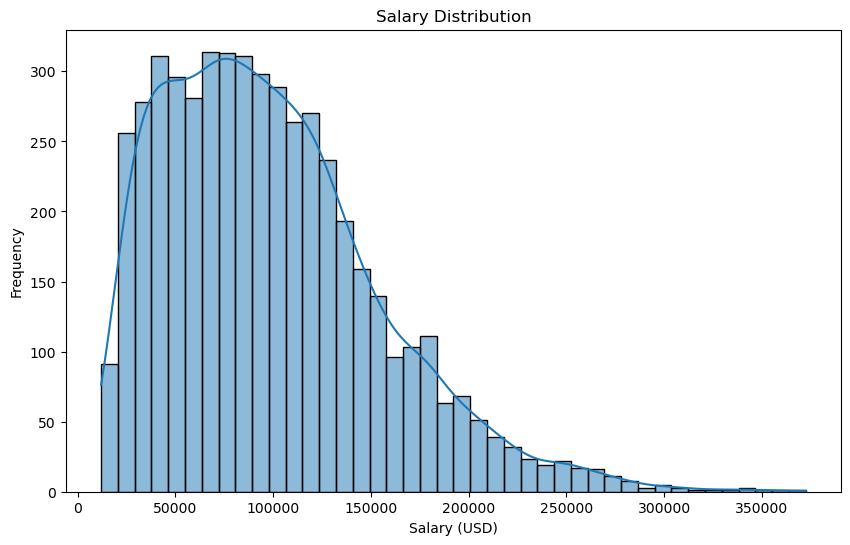

In [7]:
plt.figure(figsize=(10, 6))

sns.histplot(df["salary_usd"], kde=True)

plt.title("Salary Distribution")
plt.xlabel("Salary (USD)")
plt.ylabel("Frequency")

plt.show()

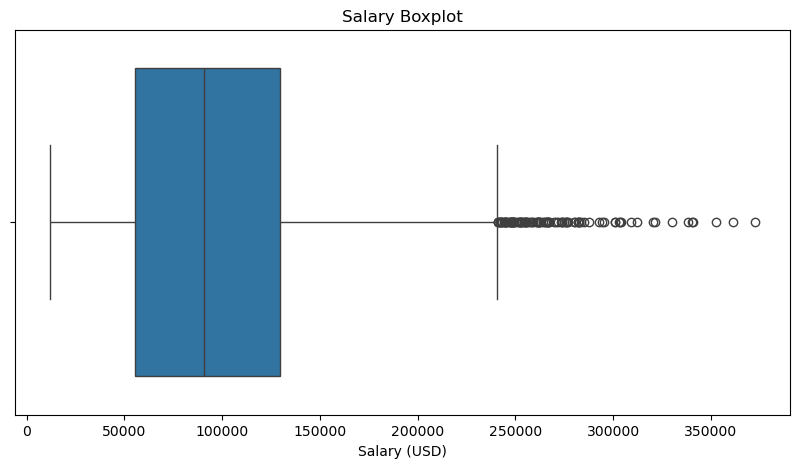

In [8]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["salary_usd"])

plt.title("Salary Boxplot")
plt.xlabel("Salary (USD)")

plt.show()

# Salary by Experience level

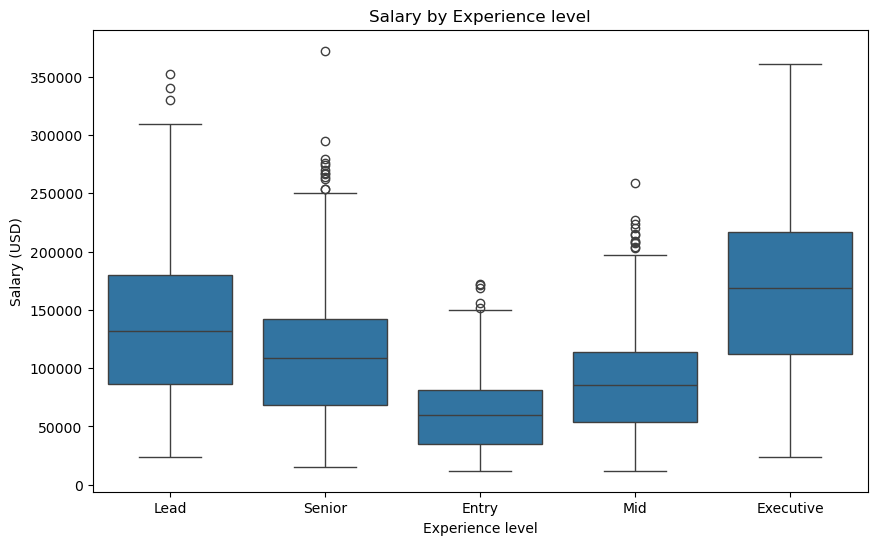

In [9]:
plt.figure(figsize = (10,6))

sns.boxplot(data=df, x="experience_level", y="salary_usd")

plt.title("Salary by Experience level")
plt.xlabel("Experience level")
plt.ylabel("Salary (USD)")

plt.show()

In [10]:
df.groupby("experience_level")["salary_usd"].mean().sort_values(ascending=False)

experience_level
Executive    164659.194690
Lead         136346.597561
Senior       109747.303947
Mid           86464.457533
Entry         61002.652792
Name: salary_usd, dtype: float64

# Salary by Employment Type

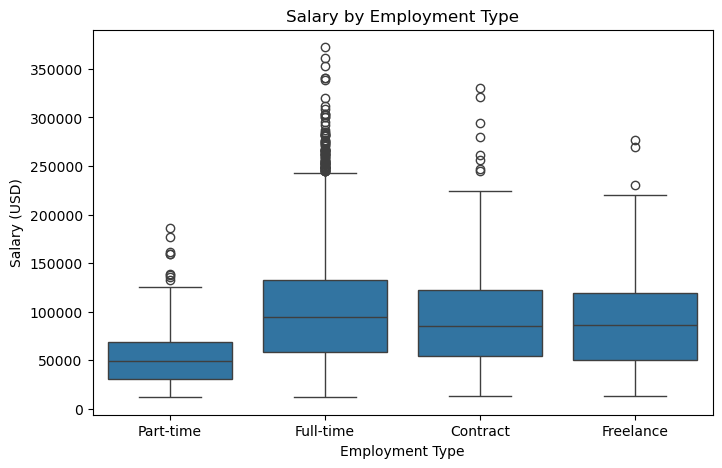

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="employment_type", y="salary_usd")

plt.title("Salary by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Salary (USD)")

plt.show()

# Salary by Job Title

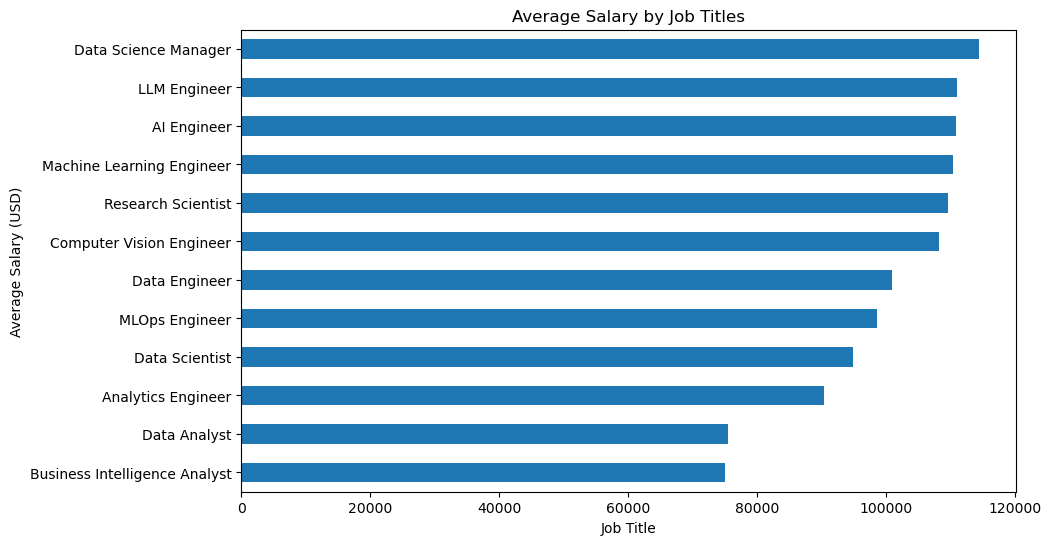

In [12]:
job_salary = df.groupby("job_title")["salary_usd"].mean().sort_values(ascending=True)

plt.figure(figsize=(10,6))

job_salary.plot(kind="barh")

plt.title("Average Salary by Job Titles")
plt.ylabel("Average Salary (USD)")
plt.xlabel("Job Title")

plt.show()

# Salary by Education level

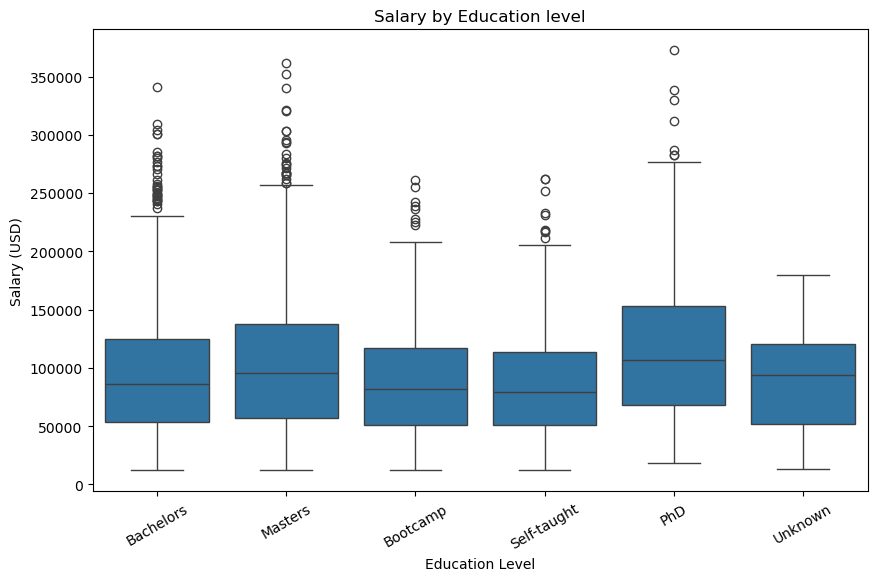

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x="education_level", y="salary_usd")

plt.title("Salary by Education level")
plt.xlabel("Education Level")
plt.ylabel("Salary (USD)")

plt.xticks(rotation=30)

plt.show()

# Salary by Primary Language

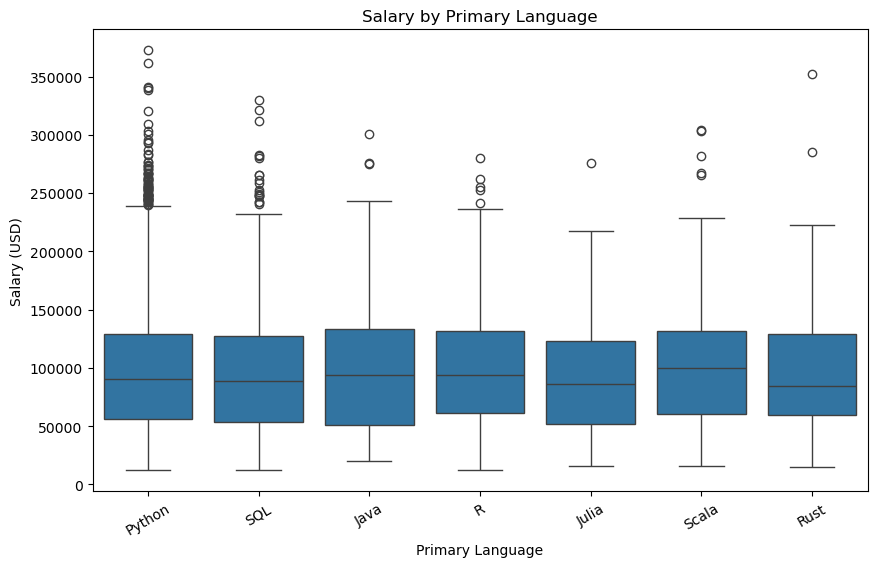

In [14]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x="primary_language", y="salary_usd")

plt.title("Salary by Primary Language")
plt.xlabel("Primary Language")
plt.ylabel("Salary (USD)")

plt.xticks(rotation=30)

plt.show()

In [15]:
df.groupby("primary_language")["salary_usd"].mean().sort_values(ascending=False)

primary_language
Scala     102419.018265
Java      100244.515625
R         100232.777003
Python     98881.004768
Rust       97610.461538
SQL        96633.823465
Julia      91613.323529
Name: salary_usd, dtype: float64

# Salary by Company Size

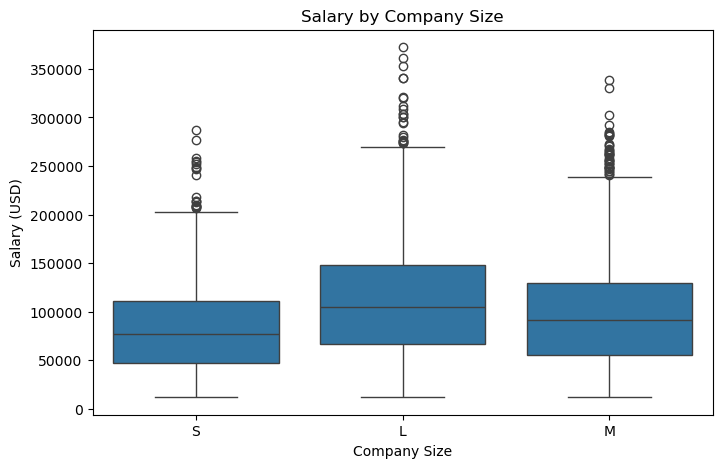

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="company_size", y="salary_usd")

plt.title("Salary by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Salary (USD)")

plt.show()

# Salary by Years of Experience

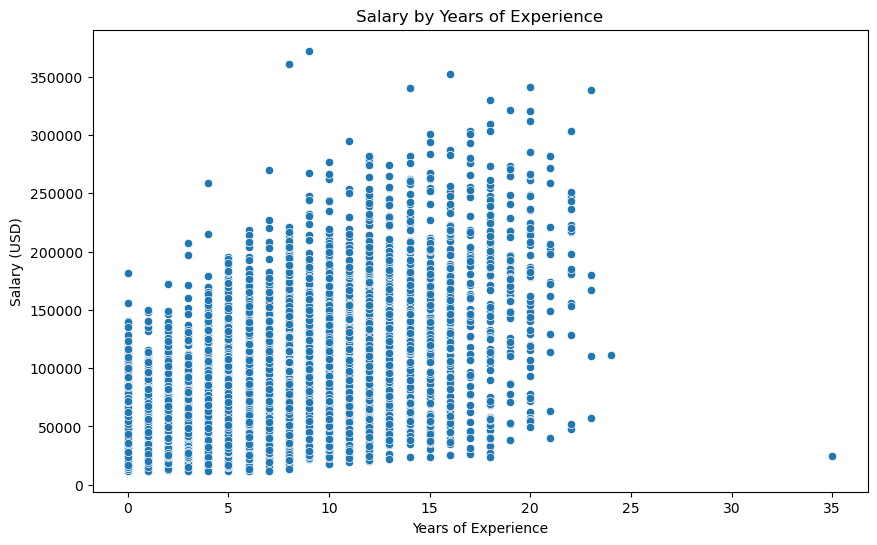

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df, x="years_experience", y="salary_usd")

plt.title("Salary by Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (USD)")

plt.show()

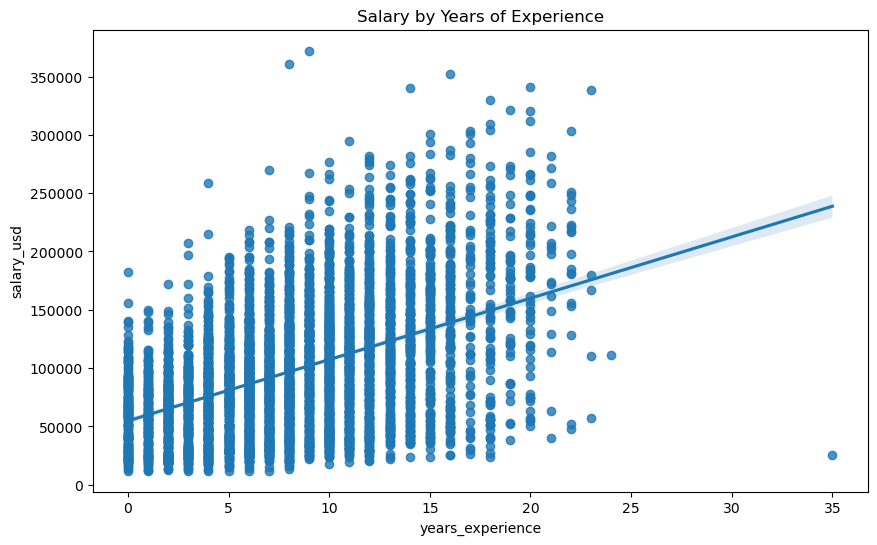

In [18]:
plt.figure(figsize=(10,6))

sns.regplot(data=df, x="years_experience", y="salary_usd")

plt.title("Salary by Years of Experience")

plt.show()

# Salary by Team Size

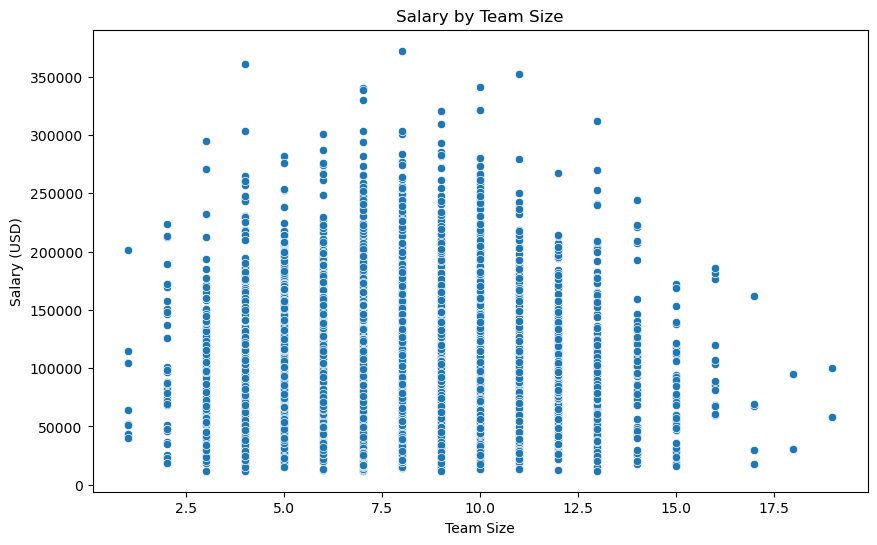

In [19]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df, x="team_size", y="salary_usd")

plt.title("Salary by Team Size")
plt.xlabel("Team Size")
plt.ylabel("Salary (USD)")

plt.show()

In [20]:
df.groupby("team_size")["salary_usd"].mean().sort_values(ascending=False)

team_size
13    104123.186567
16    103877.466667
11    101307.777126
10    101218.845850
2     100489.333333
14    100294.433333
8      99895.669366
12     99222.552036
9      98763.583463
7      98223.115747
6      98111.993760
5      96771.008475
3      95962.452830
4      93144.604895
15     80636.947368
1      79422.555556
19     79190.500000
18     73446.333333
17     69095.400000
Name: salary_usd, dtype: float64

# Salary by Company Location

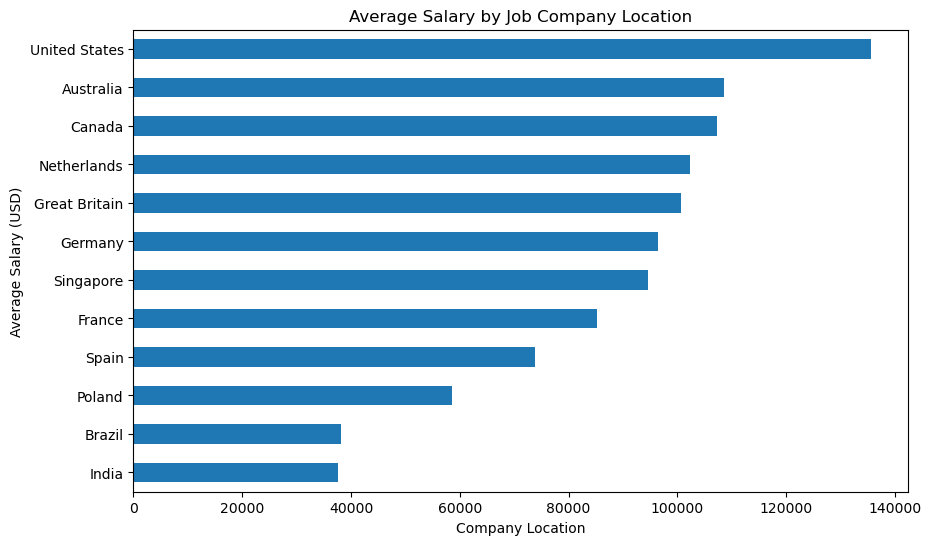

In [21]:
company_location_salary = df.groupby("company_location_name")["salary_usd"].mean().sort_values(ascending=True)

plt.figure(figsize=(10,6))

company_location_salary.plot(kind="barh")

plt.title("Average Salary by Job Company Location")
plt.ylabel("Average Salary (USD)")
plt.xlabel("Company Location")

plt.show()

In [22]:
df.groupby("company_location_name")["salary_usd"].mean().sort_values(ascending=False)

company_location_name
United States    135662.267637
Australia        108565.245833
Canada           107260.702857
Netherlands      102304.445000
Great Britain    100562.028689
Germany           96418.974286
Singapore         94549.830769
France            85178.455026
Spain             73861.109375
Poland            58488.816327
Brazil            38230.252381
India             37576.571611
Name: salary_usd, dtype: float64

# Salary by Industry

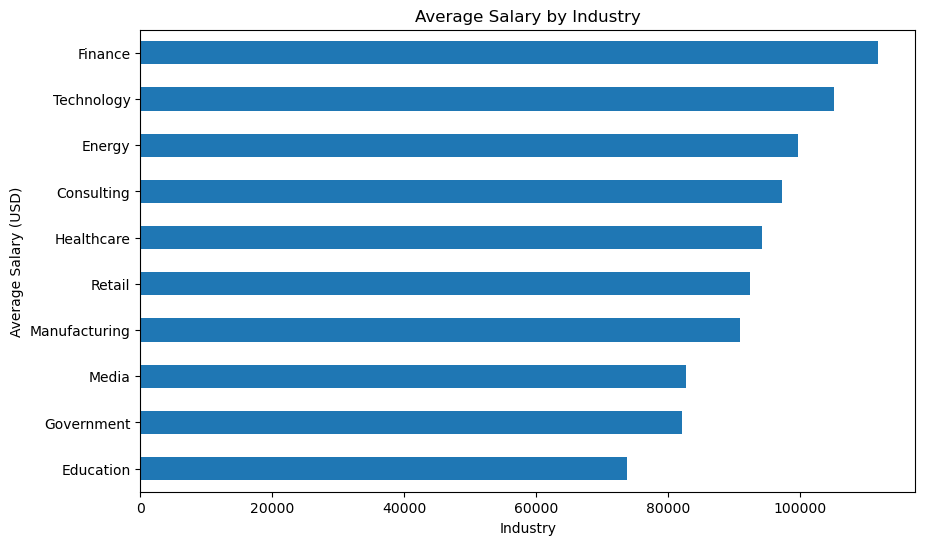

In [23]:
industry_salary = df.groupby("industry")["salary_usd"].mean().sort_values(ascending=True)

plt.figure(figsize=(10,6))

industry_salary.plot(kind="barh")

plt.title("Average Salary by Industry")
plt.ylabel("Average Salary (USD)")
plt.xlabel("Industry")

plt.show()

# Salary by Using AI Tools

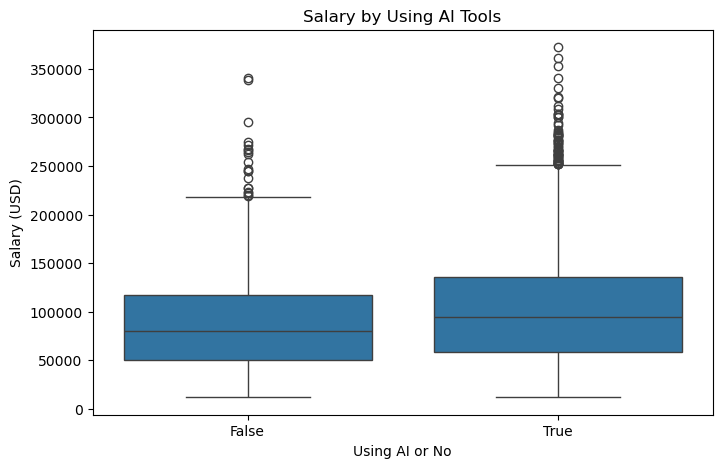

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="uses_ai_tools_daily", y="salary_usd")

plt.title("Salary by Using AI Tools")
plt.xlabel("Using AI or No")
plt.ylabel("Salary (USD)")

plt.show()

# Salary by AI Tools Usage

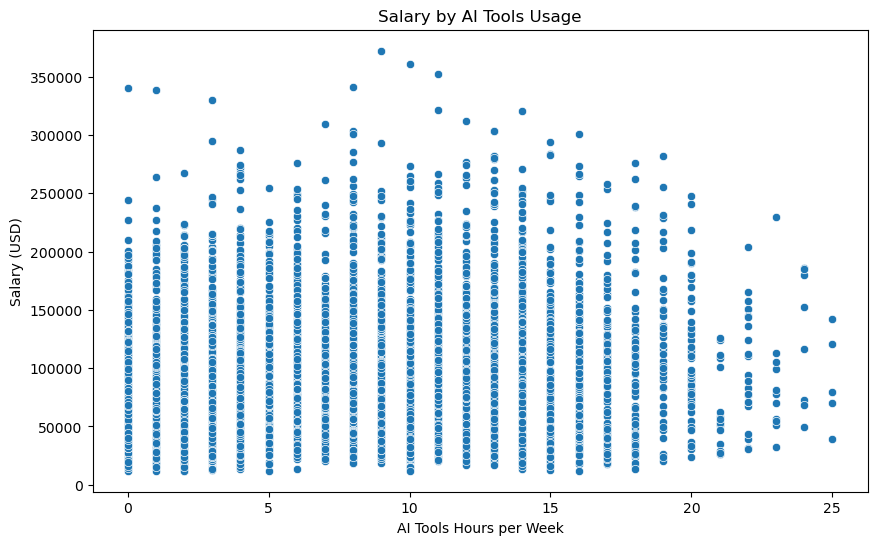

In [25]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df, x="ai_tools_hours_per_week", y="salary_usd")

plt.title("Salary by AI Tools Usage")
plt.xlabel("AI Tools Hours per Week")
plt.ylabel("Salary (USD)")

plt.show()

In [26]:
df.groupby("ai_tools_hours_per_week")["salary_usd"].mean().sort_values(ascending=False)

ai_tools_hours_per_week
24    126412.500000
19    124578.170213
20    108281.679245
13    106690.430328
11    105442.821818
8     105055.947368
6     103897.344828
22    103304.217391
9     103059.614173
14    102896.658065
16    101614.390625
10    101338.821918
12     99857.113208
7      99383.952632
17     99332.125000
15     98511.755682
18     97186.133333
4      96648.247492
5      96515.625641
1      91671.625000
25     90355.800000
3      89466.915730
0      89047.824268
2      88735.321596
23     88269.909091
21     67752.117647
Name: salary_usd, dtype: float64

# Salary by Certifications 

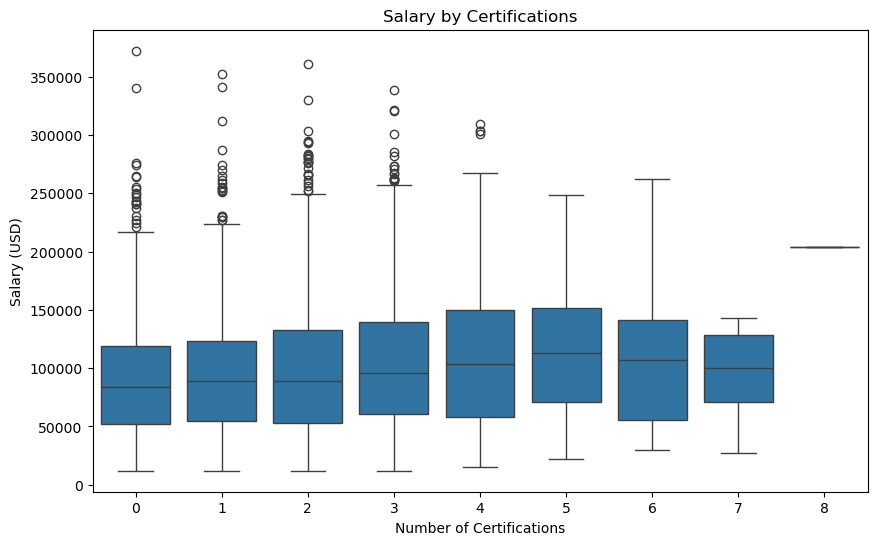

In [27]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x="certifications_count", y="salary_usd")

plt.title("Salary by Certifications")
plt.xlabel("Number of Certifications")
plt.ylabel("Salary (USD)")

plt.show()

In [28]:
df.groupby("certifications_count")["salary_usd"].mean().sort_values(ascending=False)

certifications_count
8    204325.000000
5    114586.916667
6    111913.428571
4    109284.319261
3    104365.629114
2     99022.527326
7     96190.875000
1     94551.586854
0     91109.831658
Name: salary_usd, dtype: float64

# Salary by Remote Ratio

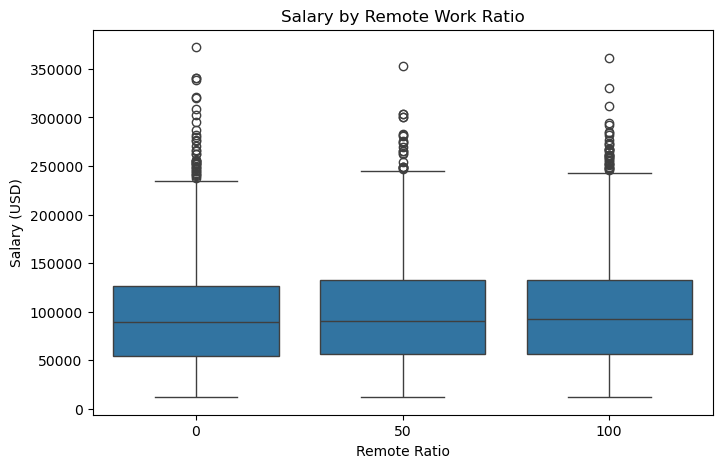

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="remote_ratio", y="salary_usd")

plt.title("Salary by Remote Work Ratio")
plt.xlabel("Remote Ratio")
plt.ylabel("Salary (USD)")

plt.show()

In [30]:
df.groupby("remote_ratio")["salary_usd"].mean().sort_values(ascending=False)

remote_ratio
100    100996.302113
50      99671.175749
0       96257.100379
Name: salary_usd, dtype: float64

# Correlation Matrix

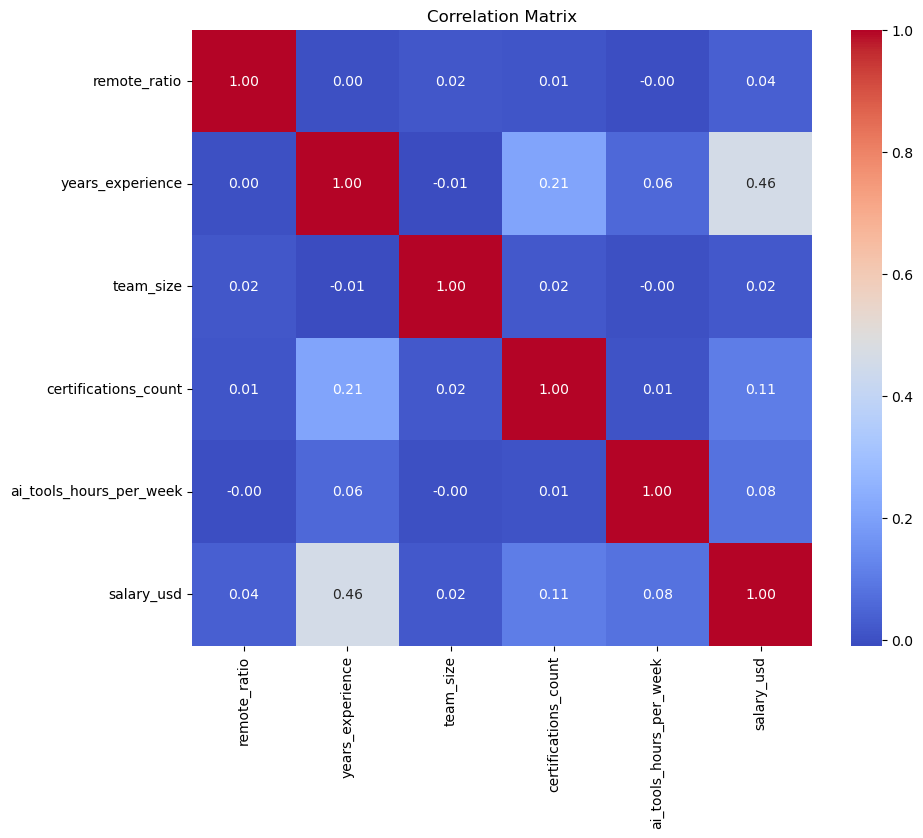

In [31]:
numeric_cols = df.select_dtypes(include=np.number)

correlation = numeric_cols.corr()

plt.figure(figsize=(10,8))

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")

plt.show()